# Задание

Вариант 1. Модель LIF-нейрона
Реализуйте класс LIFNeuron (Leaky Integrate-and-Fire), который моделирует поведение спайкового нейрона. Класс должен включать параметры: мембранный потенциал, порог срабатывания, потенциал покоя, постоянную времени. Реализуйте метод step, который принимает входной ток и обновляет состояние нейрона. При превышении порога генерируется спайк, и потенциал сбрасывается. Постройте график мембранного потенциала при постоянном входном токе.

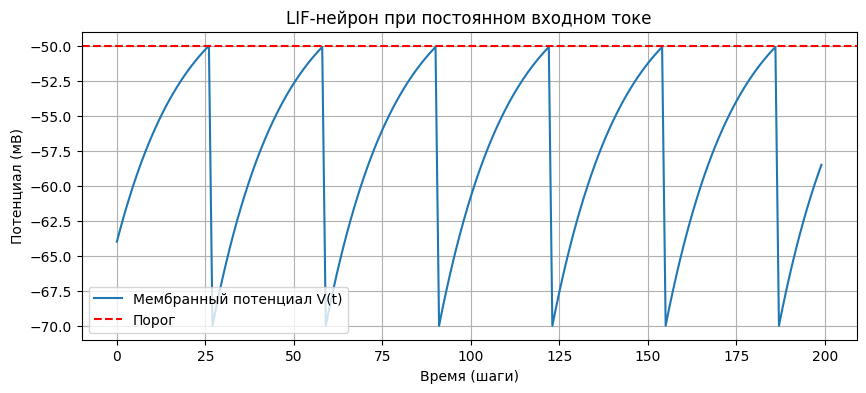

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class LIFNeuron:
    def __init__(self, v_rest=-65.0, v_reset=-70.0, v_th=-50.0, tau=20.0, R=1.0, dt=1.0):
        self.v_rest = v_rest     
        self.v_reset = v_reset    
        self.v_th = v_th          
        self.tau = tau            
        self.R = R                
        self.dt = dt              
        self.v = v_rest           

    def step(self, I):
        dv = (-(self.v - self.v_rest) + self.R * I) * (self.dt / self.tau)
        self.v += dv

        spike = 0
        if self.v >= self.v_th:
            spike = 1
            self.v = self.v_reset

        return spike, self.v


T = 200           
I_const = 20.0       

neuron = LIFNeuron()

voltages = []
spikes = []

for t in range(T):
    spike, v = neuron.step(I_const)
    voltages.append(v)
    spikes.append(spike)

plt.figure(figsize=(10, 4))
plt.plot(voltages, label="Мембранный потенциал V(t)")
plt.axhline(neuron.v_th, color="red", linestyle="--", label="Порог")
plt.xlabel("Время (шаги)")
plt.ylabel("Потенциал (мВ)")
plt.title("LIF-нейрон при постоянном входном токе")
plt.legend()
plt.grid(True)
plt.show()